# <font color='seablue'>**Assignment: Multinomial Naive Bayes**
### SMS Spam Classification
**Total Marks: 20**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### <font color = "orange"> Q1. Load the SMS Spam Collection dataset from: https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv (1 Mark)

In [2]:
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

# this a tab separated file (tsv)
df = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])
print("Shape of dataset =", df.shape)
df.head()

Shape of dataset = (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


### <font color = "orange"> Q2. Check for and handle duplicate entries and missing values in the dataset. (2 Marks)

In [3]:
# check duplicates
duplicates = df.duplicated()
print("Count of duplicated values: ", duplicates.sum())
df[duplicates]

Count of duplicated values:  403


,label,message
103,ham,As per your request 'Melle Melle (Oru Minnamin...
154,ham,As per your request 'Melle Melle (Oru Minnamin...
207,ham,"As I entered my cabin my PA said, '' Happy B'd..."
223,ham,"Sorry, I'll call later"
326,ham,No calls..messages..missed calls
...,...,...
5524,spam,You are awarded a SiPix Digital Camera! call 0...
5535,ham,"I know you are thinkin malaria. But relax, chi..."
5539,ham,Just sleeping..and surfing
5553,ham,Hahaha..use your brain dear


In [4]:
# drop duplicates
df = df.drop_duplicates()
print("Count of duplicated values: ", df.duplicated().sum())

Count of duplicated values:  0


In [5]:
# check missing values
missing = df.isna()
print("Count of missing values:")
print(missing.sum())

Count of missing values:
label      0
message    0
dtype: int64


**Observation**

***No missing values found***, so no need to handle separately.

### <font color = "orange"> Q3. Show the class distribution of the dataset and state whether the dataset is well balanced or not. (2 Marks)

In [6]:
print("Class Distribution")
class_distribution = df['label'].value_counts()
print(class_distribution)

Class Distribution
label
ham     4516
spam     653
Name: count, dtype: int64


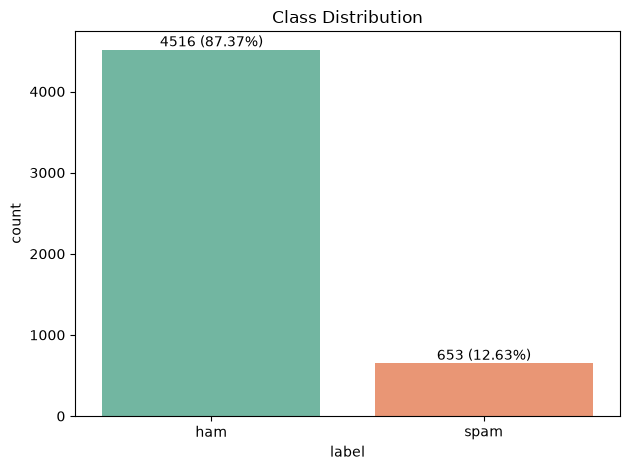

In [7]:
# plot the class distribution
class_percentage = df['label'].value_counts(normalize=True) * 100
ax = sns.countplot(data=df, x="label", hue="label", palette='Set2', legend=False)
for i in range(len(class_distribution)):
    ax.text(i, class_distribution.iloc[i], f"{class_distribution.iloc[i]} ({class_percentage.iloc[i]:.2f}%)", ha="center", va="bottom")
plt.title("Class Distribution")
plt.tight_layout()
plt.savefig('plots/class_dist.png')

**Observation**

The dataset contains `87.37% ham` and `12.63% spam` messages. Hence, the dataset is **imbalanced**, as the 'ham' class significantly outnumbers the 'spam' class.

### <font color = "orange"> Q4. Preprocess the message text (convert to lowercase and remove punctuation) so it's ready for vectorization. (2 Marks)

In [8]:
import string

# convert to lower case
df['message'] = df['message'].str.lower()

# remove punctuations
df['message'] = df['message'].str.translate(str.maketrans("", "", string.punctuation))
df.head()

,label,message
0,ham,go until jurong point crazy available only in ...
1,ham,ok lar joking wif u oni
2,spam,free entry in 2 a wkly comp to win fa cup fina...
3,ham,u dun say so early hor u c already then say
4,ham,nah i dont think he goes to usf he lives aroun...


In [9]:
# separate feature and target class
x = df['message']
y = df['label']
print("X shape:", x.shape)
print("Y shape:", y.shape)

X shape: (5169,)
Y shape: (5169,)


### <font color = "orange"> Q5. Split the dataset into training and test sets (80%-20%). (1 Mark)

##### <font color='pink'>We split on the raw text **before** vectorizing, so that the vocabulary used in Q6 is built only from the training set — fitting the vectorizer on the full dataset (train + test) would leak test-set vocabulary into training, which is a subtle form of data leakage.

In [10]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

print(f'Shape of Training data: X = {x_train.shape} Y = {y_train.shape}')
print(f'Shape of Testing data: X = {x_test.shape} Y = {y_test.shape}')

print("\nClass distribution in training set:")
print(y_train.value_counts())

print("\nClass distribution in test set:")
print(y_test.value_counts())

Shape of Training data: X = (4135,) Y = (4135,)
Shape of Testing data: X = (1034,) Y = (1034,)

Class distribution in training set:
label
ham     3613
spam     522
Name: count, dtype: int64

Class distribution in test set:
label
ham     903
spam    131
Name: count, dtype: int64


### <font color = "orange"> Q6. Convert the preprocessed messages into count vectors (bag-of-words) using CountVectorizer, fitting only on the training data. (2 Marks)

##### <font color='pink'>A **bag-of-words** representation turns each message into a vector of word counts against a fixed vocabulary — e.g. the message `"free entry free"` becomes a vector where the column for `"free"` has value 2, `"entry"` has value 1, and every other vocabulary word is 0. This is exactly the kind of count data Multinomial Naive Bayes is built for. We cap the vocabulary size and drop common English stopwords to keep the feature space manageable and focused on informative words.

In [11]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words="english")

# learn the vocabulary from training data and convert messages into count vectors
x_train_count = vectorizer.fit_transform(x_train)

# convert test messages using the vocabulary learned from training data
x_test_count = vectorizer.transform(x_test)

print("Training data shape:", x_train_count.shape)
print("Testing data shape:", x_test_count.shape)

Training data shape: (4135, 8094)
Testing data shape: (1034, 8094)


### <font color = "orange"> Q7. Design a Multinomial Naive Bayes classifier from scratch and fit it on the training set. (6 Marks)

##### <font color='pink'>**Idea:** Multinomial NB models each class $C$ as having its own word-usage distribution — feature $i$ (word $i$) occurs with probability $p_{C,i}$ within class $C$'s documents. For a document with word counts $x_1, \ldots, x_n$, the likelihood is:$$P(\mathbf{x} \mid C) \;\propto\; \prod_{i=1}^{n} p_{C,i}^{\,x_i}$$(The multinomial coefficient $\frac{(\sum_i x_i)!}{\prod_i x_i!}$ is dropped since it's the same for every class and doesn't affect which class has the highest posterior.) We estimate $p_{C,i}$ from training data with **Laplace (add-$\alpha$) smoothing**, so a word that never appeared in class $C$'s training documents doesn't get assigned zero probability:$$p_{C,i} = \frac{N_{C,i} + \alpha}{N_C + \alpha n}$$where $N_{C,i}$ is the total count of word $i$ across all class-$C$ documents, $N_C$ is the total word count across all class-$C$ documents, and $n$ is the vocabulary size. Combined with the class prior $P(C)$, we predict the class maximizing (in log-space, to avoid underflow):$$\log P(C \mid \mathbf{x}) \;\propto\; \log P(C) + \sum_{i=1}^{n} x_i \log p_{C,i}$$

In [12]:
class MultinomialNaiveBayes:
    def __init__(self, alpha=0.1):
        """
        Model parameters
        """
        self.alpha = alpha      # smoothing parameter
        self.classes = None
        self.class_priors = None
        self.word_probabilities = None
        
    def fit(self, x, y):
        """
        Train the model
        """
        self.classes = np.unique(y)     # identify classes
        n_classes = len(self.classes)   # count of classes
        n_features = x.shape[1]         # count of words (features)
        
        # initialize probabilities
        self.class_priors = np.zeros(n_classes)
        self.word_probabilities = np.zeros((n_classes, n_features))
        
        for i, c in enumerate(self.classes):
            x_c = x[y == c]
            self.class_priors[i] = x_c.shape[0] / x.shape[0]    # calculate prior p(c) using class frequency
            word_counts = np.asarray(x_c.sum(axis=0)).ravel()   # count of each word across all messages in class c
            total_word_count = word_counts.sum()                # total number of words in class c
            
            # Laplace smoothened word probability p(word | c)
            self.word_probabilities[i, :] = (word_counts + self.alpha) / (total_word_count + self.alpha * n_features)
    
    def compute_likelihood(self, x):
        """
        Compute the Likelihood  p(x | c) for each class c
        where p(x | c) = PROD p(word | c) ** count(word) in x; for all word in sample x
        """
        n_samples = x.shape[0]
        n_classes = len(self.classes)
        likelihoods = np.zeros((n_samples, n_classes))
        
        for i in range(n_classes):
            for j in range(n_samples):
                word_counts = x[j, :].toarray().ravel()         # count of words in j'th samples
                likelihoods[j, i] = np.prod(self.word_probabilities[i, :] ** word_counts)
        return likelihoods         
    
    def predict(self, x):
        """
        Make predictions on x
        """
        likelihoods = self.compute_likelihood(x)                    # compute likelihood
        posteriors = likelihoods * self.class_priors                # compute posterior
        predictions = self.classes[np.argmax(posteriors, axis=1)]   # pick the class with max. posterior
        return predictions

In [13]:
# initialize and fit the model
my_multinomial_nb = MultinomialNaiveBayes(alpha=1)
my_multinomial_nb.fit(x_train_count, y_train.to_numpy())

### <font color = "orange"> Q8. Evaluate the test set using your custom Multinomial NB classifier and report accuracy, precision, recall, and confusion matrix. (2 Marks)

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# make predictions on test dataset
y_pred = my_multinomial_nb.predict(x_test_count)

# calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label='spam')
recall = recall_score(y_test, y_pred, pos_label='spam')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

Accuracy: 0.9797
Precision: 0.9508
Recall: 0.8855


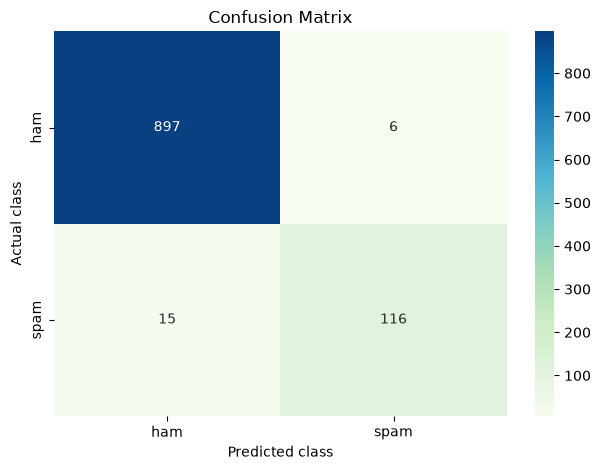

In [15]:
from sklearn.metrics import confusion_matrix

# compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# plot the confusion matrix
labels = ['ham', 'spam']
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='GnBu')
plt.title('Confusion Matrix')
plt.xlabel('Predicted class')
plt.ylabel('Actual class')
plt.tight_layout()
plt.savefig('plots/confusion_matrix.png')

**Observation**

The model achieved high overall performance with ***high precision and recall***, despite the ***class imbalance***. It correctly classifies most messages with relatively few false-positive and false-negative predictions.

### <font color = "orange"> Q9. Using scikit-learn's implementation of Multinomial NB, fit the training data and evaluate on the test set. How does the performance of this model compare with your custom implementation? (2 Marks)

In [16]:
from sklearn.naive_bayes import MultinomialNB

# initialize and fit on training data
sk_multinomial_nb = MultinomialNB(alpha=1)
sk_multinomial_nb.fit(x_train_count, y_train.to_numpy())

# make predictions on test set
y_pred_sk = sk_multinomial_nb.predict(x_test_count)

In [17]:
# calculate evaluation metrics
accuracy_sk = accuracy_score(y_test, y_pred_sk)
precision_sk = precision_score(y_test, y_pred_sk, pos_label='spam')
recall_sk = recall_score(y_test, y_pred_sk, pos_label='spam')

# compare the models
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall'],
    'From-scratch model': [accuracy, precision, recall],
    'Sk-learn model': [accuracy_sk, precision_sk, recall_sk]
})
display(comparison)

,Metric,From-scratch model,Sk-learn model
0,Accuracy,0.979691,0.979691
1,Precision,0.950820,0.950820
2,Recall,0.885496,0.885496


**Observation**

The `from-scratch` implementation of `Multinomial Naive Bayes classifier` ***produces the same accuracy, precision and recall*** as `Scikit-learn's MultinomialNB` with `alpha=1`. This confirms that the implementation correctly applies the class priors, word probabilities, and Laplace smoothing.

---
End of the assignment